In [1]:
import copy
import numpy as np
import scipy
import pandas
import matplotlib.pyplot as plt

# $k$-nn and cross-validation

The goal of this tutorial is to manipulate a dataset with `polars`, perform the $k$-nearest neighbors methods with `sklearn`, and use cross-validation to select the best $k$.

The dataset is a [breast cancer dataset](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset) from kaggle: each indivual is associated with features provided by medical imaging and a diagnosis. The diagnosis of the tumor can be either **M**alignant (cancerous) or **B**enign (non-cancerous). We will use this dataset to test the $k$-nn method.

## Dataset manipulation

**Question 1**

Load the dataset `breast_cancer.csv` with `pandas`. One can use `pandas.read_csv`, which returns a `pandas.DataFrame`. We will name it `df`.

Print `df`.

In [2]:
df = pandas.read_csv("breast_cancer.csv")
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


**Question 2**

Extract the labels of the columns of `df` with the attribute `columns`. 

Identify the label corresponding to the classification target and extract the classes automatically. One can extract from a `DataFrame` a column with name `colname` by using the accessor `[colname]`, and one can build the list of different elements in that column with the method `unique`.

Name a column that is irrelevant for the classification process.

Print the labels of the columns and the name of the classes.

In [3]:
columns = df.columns
print("Columns:", columns)

target = "diagnosis"
classes = list(df[target].unique())
print("Classes:", classes)

# Irrelevant column for classification: "id"

Columns: Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')
Classes: ['M', 'B']


**Question 3**

Build a new `DataFrame` by selecting only two features ("radius_mean" and "texture_mean") and the target column. One can use the `DataFrame` operator `[...]`.

Print the new `DataFrame`.

In [4]:
features = ["radius_mean", "texture_mean"]

df = df[features + [target]]
df

,radius_mean,texture_mean,diagnosis
0,17.99,10.38,M
1,20.57,17.77,M
2,19.69,21.25,M
3,11.42,20.38,M
4,20.29,14.34,M
...,...,...,...
564,21.56,22.39,M
565,20.13,28.25,M
566,16.60,28.08,M
567,20.60,29.33,M


**Question 4**

Make the scatter plot of the features that have been selected, and use different colors for the points belonging to different classes.

To select the rows of a `DataFrame` `df` matching a certain condition, one can use `df[df[some_column_name] == value]`, where the operator `==` can be replaced by any comparison operator.

Note: a `pandas.DataFrame` object can be converted to a `numpy.array` object by using the method `to_numpy`.

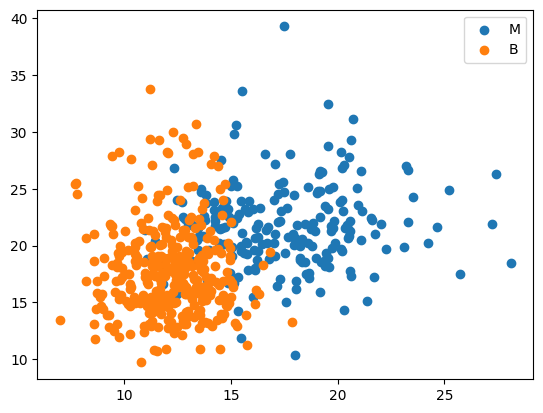

In [5]:
for cl in classes:
    data = df[df[target] == cl][features]
    data = data.to_numpy()
    plt.scatter(data[:,0], data[:,1], label = cl)
    
plt.legend()

**Question 5**

Build the `DataFrame` containing the features and the `Series` containing the target labels. The first will be named `X`, and the second `y`.

In [6]:
X = df[features]
y = df[target]

## $k$-nn with 2 features and decision boundaries

**Question 6**

Split the dataset into a train set and a test set, where the size of the test set is 20% of the size of the entire dataset. One can use the function `sklearn.model_selection.train_test_split`.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

**Question 7**

Perform a classification with the $k$-nn method with $k = 5$. Show the train score and the test score. One can [read the documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) about the class `sklearn.neighbors.KNeighborsClassifier`.

Propose a formula for the loss, based on the `score`.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, metric = "l2")
knn.fit(X_train, y_train)

score_train = knn.score(X_train, y_train)
score_test = knn.score(X_test, y_test)

print("score train:", score_train)
print("score test:", score_test)

# The score is the proportion of data points that have been well classified,
# so it is reasonable to compute 1 - score to get a loss to minimize
loss_train = 1 - score_train
loss_test = 1 - score_test

print("training loss:", loss_train)
print("test loss:", loss_test)

score train: 0.9032967032967033
score test: 0.8771929824561403
training loss: 0.09670329670329669
test loss: 0.1228070175438597


**Question 8**

Plot the decision boundaries by using the function `from sklearn.inspection.DecisionBoundaryDisplay`. [Read to documentation](https://scikit-learn.org/dev/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html). At some point, it would be helpful to use `plt.subplots()`.

On the same figure, perform the scatter plot of the training data.

On another figure, plot the decision boundaries and the test data points.

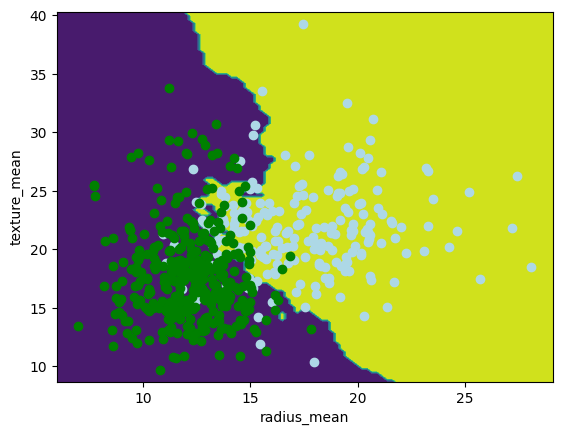

In [9]:
from sklearn.inspection import DecisionBoundaryDisplay

_, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(knn, X, ax=ax, response_method="predict")

colors = ["lightblue", "green"]
for i, cl in enumerate(classes):
    data = df[df[target] == cl][features]
    data = data.to_numpy()
    plt.scatter(data[:,0], data[:,1], label = cl, c = colors[i])

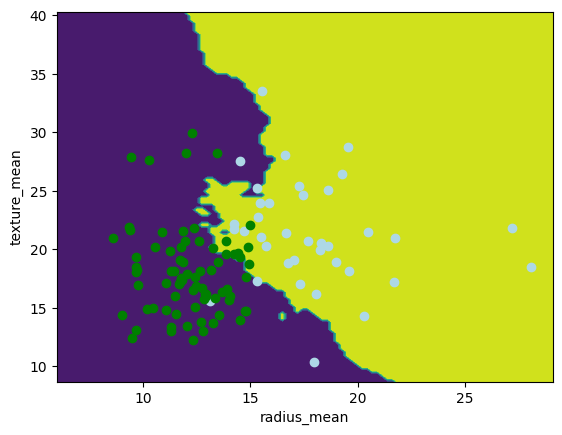

In [10]:
_, ax = plt.subplots()
DecisionBoundaryDisplay.from_estimator(knn, X, ax=ax, response_method="predict")

#df_test = X_test.join(y_test)

colors = ["lightblue", "green"]
for i, cl in enumerate(classes):
    data = X_test[y_test == cl][features]
    data = data.to_numpy()
    plt.scatter(data[:,0], data[:,1], label = cl, c = colors[i])

**Question 9**

Plot the decision boundaries for various $k$. What do we observe?

(Optional) Test also various distances (Minkowski distances with various $p$).

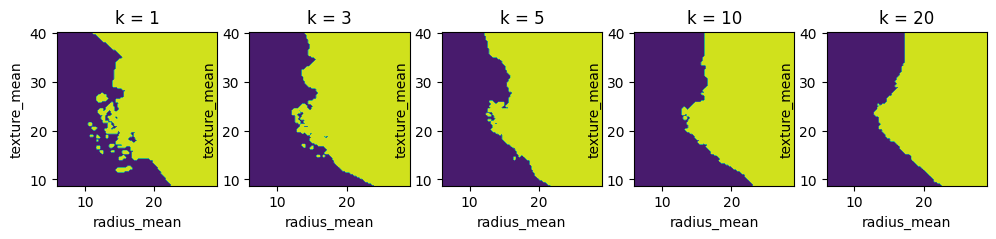

In [11]:
fig, ax = plt.subplots(1, 5)

fig.set_figwidth(12)
fig.set_figheight(2)

lst_k = [1, 3, 5, 10, 20]

for i, k in enumerate(lst_k):
    knn.set_params(n_neighbors = k).fit(X_train, y_train)
    DecisionBoundaryDisplay.from_estimator(knn, X, ax=ax[i], response_method="predict")
    ax[i].set_title(f"k = {k}")

The decision boundaries are smoother and smoother as $k$ increases.

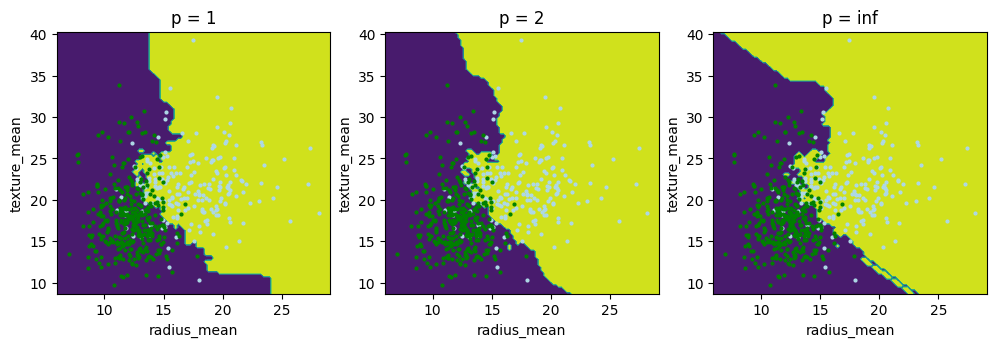

In [12]:
fig, ax = plt.subplots(1, 3)

fig.set_figwidth(12)
fig.set_figheight(3.4)

lst_p = [1, 2, np.inf]

knn.set_params(n_neighbors = 5, metric = "minkowski")
for i, p in enumerate(lst_p):
    knn.set_params(p = p).fit(X_train, y_train)
    DecisionBoundaryDisplay.from_estimator(knn, X, ax=ax[i], response_method="predict")
    ax[i].set_title(f"p = {p}")
    for j, cl in enumerate(classes):
        data = df[df[target] == cl][features]
        data = data.to_numpy()
        ax[i].scatter(data[:,0], data[:,1], label = cl, c = colors[j], s = 4)

## $k$-nn with many features and model selection

We will use all the (relevant) available features for classification, and we will select the best number of neighbors $k$ with the cross-validation procedure.

**Question 10**

Reload the dataset and select all the features (except the irrelevant ones). Build again `X` and `y`, and split the dataset into a training set and a test set.

In [13]:
df = pandas.read_csv("breast_cancer.csv")
df

columns = list(df.columns)
target = "diagnosis"
classes = list(df[target].unique())

features = copy.deepcopy(columns)
features.pop(features.index(target))   # remove the target from the features
features.pop(features.index("id"))    # the id is irrelevant for classification

df = df[features + [target]]

X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

In [14]:
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
343,19.68,21.68,129.90,1194.0,0.09797,0.13390,0.18630,0.11030,0.2082,0.05715,...,22.75,34.66,157.60,1540.0,0.12180,0.34580,0.47340,0.22550,0.4045,0.07918
323,20.34,21.51,135.90,1264.0,0.11700,0.18750,0.25650,0.15040,0.2569,0.06670,...,25.30,31.86,171.10,1938.0,0.15920,0.44920,0.53440,0.26850,0.5558,0.10240
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.13740,0.20500,0.40000,0.16250,0.2364,0.07678
165,14.97,19.76,95.50,690.2,0.08421,0.05352,0.01947,0.01939,0.1515,0.05266,...,15.98,25.82,102.30,782.1,0.10450,0.09995,0.07750,0.05754,0.2646,0.06085
440,10.97,17.20,71.73,371.5,0.08915,0.11130,0.09457,0.03613,0.1489,0.06640,...,12.36,26.87,90.14,476.4,0.13910,0.40820,0.47790,0.15550,0.2540,0.09532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,11.80,16.58,78.99,432.0,0.10910,0.17000,0.16590,0.07415,0.2678,0.07371,...,13.74,26.38,91.93,591.7,0.13850,0.40920,0.45040,0.18650,0.5774,0.10300
305,11.60,24.49,74.23,417.2,0.07474,0.05688,0.01974,0.01313,0.1935,0.05878,...,12.44,31.62,81.39,476.5,0.09545,0.13610,0.07239,0.04815,0.3244,0.06745
93,13.45,18.30,86.60,555.1,0.10220,0.08165,0.03974,0.02780,0.1638,0.05710,...,15.10,25.94,97.59,699.4,0.13390,0.17510,0.13810,0.07911,0.2678,0.06603
77,18.05,16.15,120.20,1006.0,0.10650,0.21460,0.16840,0.10800,0.2152,0.06673,...,22.39,18.91,150.10,1610.0,0.14780,0.56340,0.37860,0.21020,0.3751,0.11080


### Cross-validation

**Question 11**

Build a `sklearn.model_selection.KFold` with 5 splits, and use it to compute the validation loss for each of the 5 splits. Do not forget to [read the documentation](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.KFold.html). One can use the `iloc` attribute of `DataFrame` to access a specific subset of rows in a `DataFrame`.

Show the average validation loss on the splits.

In [15]:
from sklearn.model_selection import KFold

n_splits = 5

kfold = KFold(n_splits = n_splits)
knn = KNeighborsClassifier(n_neighbors=5, metric = "l2")

lst_losses = []
for i, (idx_train, idx_valid) in enumerate(kfold.split(X_train, y_train)):
    knn.fit(X_train.iloc[idx_train], y_train.iloc[idx_train])
    pt_loss = 1 - knn.score(X_train.iloc[idx_valid], y_train.iloc[idx_valid])
    print(f"Split {i}: {pt_loss:.4f}")
    lst_losses.append(pt_loss)
    
print(f"Average validation loss: {sum(lst_losses)/n_splits:.4f}")

Split 0: 0.0769
Split 1: 0.0549
Split 2: 0.0879
Split 3: 0.0659
Split 4: 0.0440
Average validation loss: 0.0659


**Question 12**

Now, use `sklearn.model_selection.cross_val_score` to perform cross-validation automatically. 

Given a grid of $k \in \{1, \cdots, 40\}$, compute the validation loss outputted for each $k$ and plot it with respect to $k$. Is it better to have a small $k$ or a large $k$?

Note: [read the documentation](https://scikit-learn.org/1.6/modules/generated/sklearn.model_selection.StratifiedKFold.html#sklearn.model_selection.StratifiedKFold) about `StratifiedKFold`, which is the by-default split technique used with `cross_val_score`.

In [16]:
from sklearn.model_selection import cross_val_score

n_splits = 5

knn = KNeighborsClassifier(n_neighbors = 5, metric = "l2")

lst_scores = cross_val_score(knn, X_train, y_train, cv = n_splits)
print("Scores for each split:", lst_scores)
    
print(f"Average validation loss: {1 - sum(lst_losses)/n_splits:.4f}")

Scores for each split: [0.93406593 0.91208791 0.9010989  0.95604396 0.95604396]
Average validation loss: 0.9341


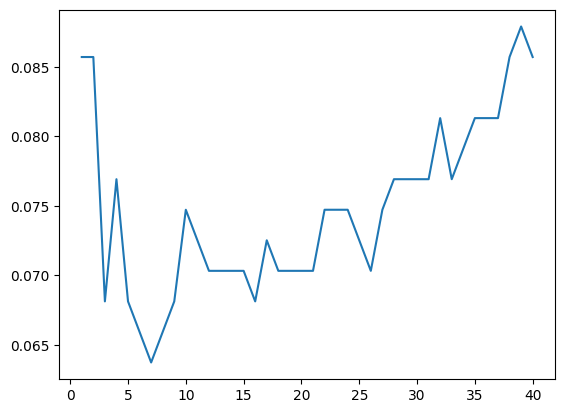

In [17]:
kmax = 40

knn = KNeighborsClassifier(n_neighbors = 5, metric = "l2")

lst_k = list(range(1, kmax + 1))
lst_losses = []
for k in lst_k:
    knn.set_params(n_neighbors = k)
    lst_scores = cross_val_score(knn, X_train, y_train, cv = n_splits)
    lst_losses.append(1 - sum(lst_scores)/n_splits)
    
plt.plot(lst_k, lst_losses)

It is better to choose a value for k that is not too large and not too small.

With small values of k, we face a kind of *overfitting*: we pay too much attention to the small irregularies corresponding to the noise present in the training dataset.

With large values of $k$, we face a kind of *underfitting*: we tend to ignore irregularities that are actually significant.

### Model selection

**Question 13**

Finally, perform cross-validation on a grid of hyperparameters $k \in \{1, \cdots, 40\}$ (the number of neighbors). Plot the validation loss with respect to $k$. Select the best $k$ and compute the test loss with it.

One can use `sklearn.model_selection.GridSearchCV` to automate the search of the best $k$. One can train it with the `fit` method, retrieve the best model in the attribute `best_estimator_`, and from there, extract the best $k$ and compute the test loss.

In [18]:
from sklearn.model_selection import GridSearchCV

n_splits = 10
kmax = 40

param_grid = {"n_neighbors": list(range(1, kmax + 1))}
grid_search = GridSearchCV(estimator = knn, param_grid = param_grid, cv = n_splits, n_jobs=-1)

In [19]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsCla..._neighbors=40)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate param

In [20]:
k_best = grid_search.best_estimator_.n_neighbors
print("Best k:", k_best)

loss_test = 1 - grid_search.best_estimator_.score(X_test, y_test)
print(f"Test loss: {loss_test:.4f}")

Best k: 3
Test loss: 0.0877
